# Machine Learning Projekt: Vehicle Classification

Dieses Notebook analysiert den Vehicle-Datensatz mit **Supervised Learning** und **Unsupervised Learning**.

- Supervised: Vorhersage der Zielvariable `class` mit Klassifikationsmodellen.
- Unsupervised: Clustering der Fahrzeuge ohne Nutzung der Zielvariable.


## 1. Setup


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, silhouette_score, adjusted_rand_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA

sns.set_theme(style='whitegrid', palette='Set2')
RANDOM_STATE = 42


## 2. Daten laden

Lade `vehicle.csv` in Colab hoch oder mounte Google Drive und passe `DATA_PATH` an.


In [5]:
# Load the data
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('vehicle.csv')
df.head()

Saving vehicle.csv to vehicle (1).csv


,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,class
0,95,48.0,83.0,178.0,72.0,10,162.0,42.0,20.0,159,176.0,379.0,184.0,70.0,6.0,16.0,187.0,197,van
1,91,41.0,84.0,141.0,57.0,9,149.0,45.0,19.0,143,170.0,330.0,158.0,72.0,9.0,14.0,189.0,199,van
2,104,50.0,106.0,209.0,66.0,10,207.0,32.0,23.0,158,223.0,635.0,220.0,73.0,14.0,9.0,188.0,196,car
3,93,41.0,82.0,159.0,63.0,9,144.0,46.0,19.0,143,160.0,309.0,127.0,63.0,6.0,10.0,199.0,207,van
4,85,44.0,70.0,205.0,103.0,52,149.0,45.0,19.0,144,241.0,325.0,188.0,127.0,9.0,11.0,180.0,183,bus


In [6]:
#DATA_PATH = 'vehicle.csv'

# Optional für Google Drive:
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_PATH = '/content/drive/MyDrive/vehicle.csv'

#df = pd.read_csv(DATA_PATH)
#df.head()


## 3. Explorative Datenanalyse


In [7]:
print('Shape:', df.shape)
display(df.info())
display(df.describe().T)

missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0])


Shape: (846, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 846 entries, 0 to 845
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   compactness                  846 non-null    int64  
 1   circularity                  841 non-null    float64
 2   distance_circularity         842 non-null    float64
 3   radius_ratio                 840 non-null    float64
 4   pr.axis_aspect_ratio         844 non-null    float64
 5   max.length_aspect_ratio      846 non-null    int64  
 6   scatter_ratio                845 non-null    float64
 7   elongatedness                845 non-null    float64
 8   pr.axis_rectangularity       843 non-null    float64
 9   max.length_rectangularity    846 non-null    int64  
 10  scaled_variance              843 non-null    float64
 11  scaled_variance.1            844 non-null    float64
 12  scaled_radius_of_gyration    844 non-null    float64
 13  sca

None

,count,mean,std,min,25%,50%,75%,max
compactness,846.0,93.678487,8.234474,73.0,87.00,93.0,100.0,119.0
circularity,841.0,44.828775,6.152172,33.0,40.00,44.0,49.0,59.0
distance_circularity,842.0,82.110451,15.778292,40.0,70.00,80.0,98.0,112.0
radius_ratio,840.0,168.888095,33.520198,104.0,141.00,167.0,195.0,333.0
pr.axis_aspect_ratio,844.0,61.678910,7.891463,47.0,57.00,61.0,65.0,138.0
max.length_aspect_ratio,846.0,8.567376,4.601217,2.0,7.00,8.0,10.0,55.0
scatter_ratio,845.0,168.901775,33.214848,112.0,147.00,157.0,198.0,265.0
elongatedness,845.0,40.933728,7.816186,26.0,33.00,43.0,46.0,61.0
pr.axis_rectangularity,843.0,20.582444,2.592933,17.0,19.00,20.0,23.0,29.0
max.length_rectangularity,846.0,147.998818,14.515652,118.0,137.00,146.0,159.0,188.0


,0
radius_ratio,6
skewness_about,6
circularity,5
scaled_radius_of_gyration.1,4
distance_circularity,4
scaled_variance,3
pr.axis_rectangularity,3
scaled_variance.1,2
scaled_radius_of_gyration,2
pr.axis_aspect_ratio,2


,count
class,
car,429
bus,218
van,199


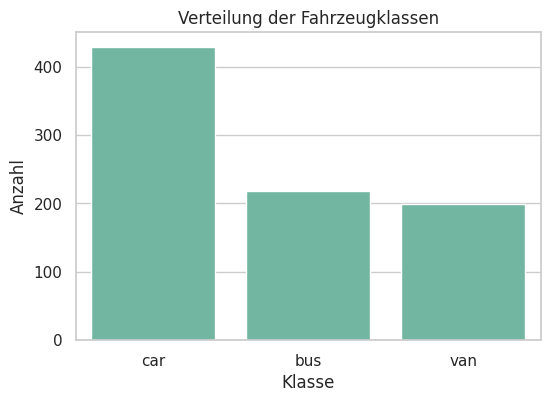

In [8]:
class_counts = df['class'].value_counts()
display(class_counts)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='class', order=class_counts.index)
plt.title('Verteilung der Fahrzeugklassen')
plt.xlabel('Klasse')
plt.ylabel('Anzahl')
plt.show()


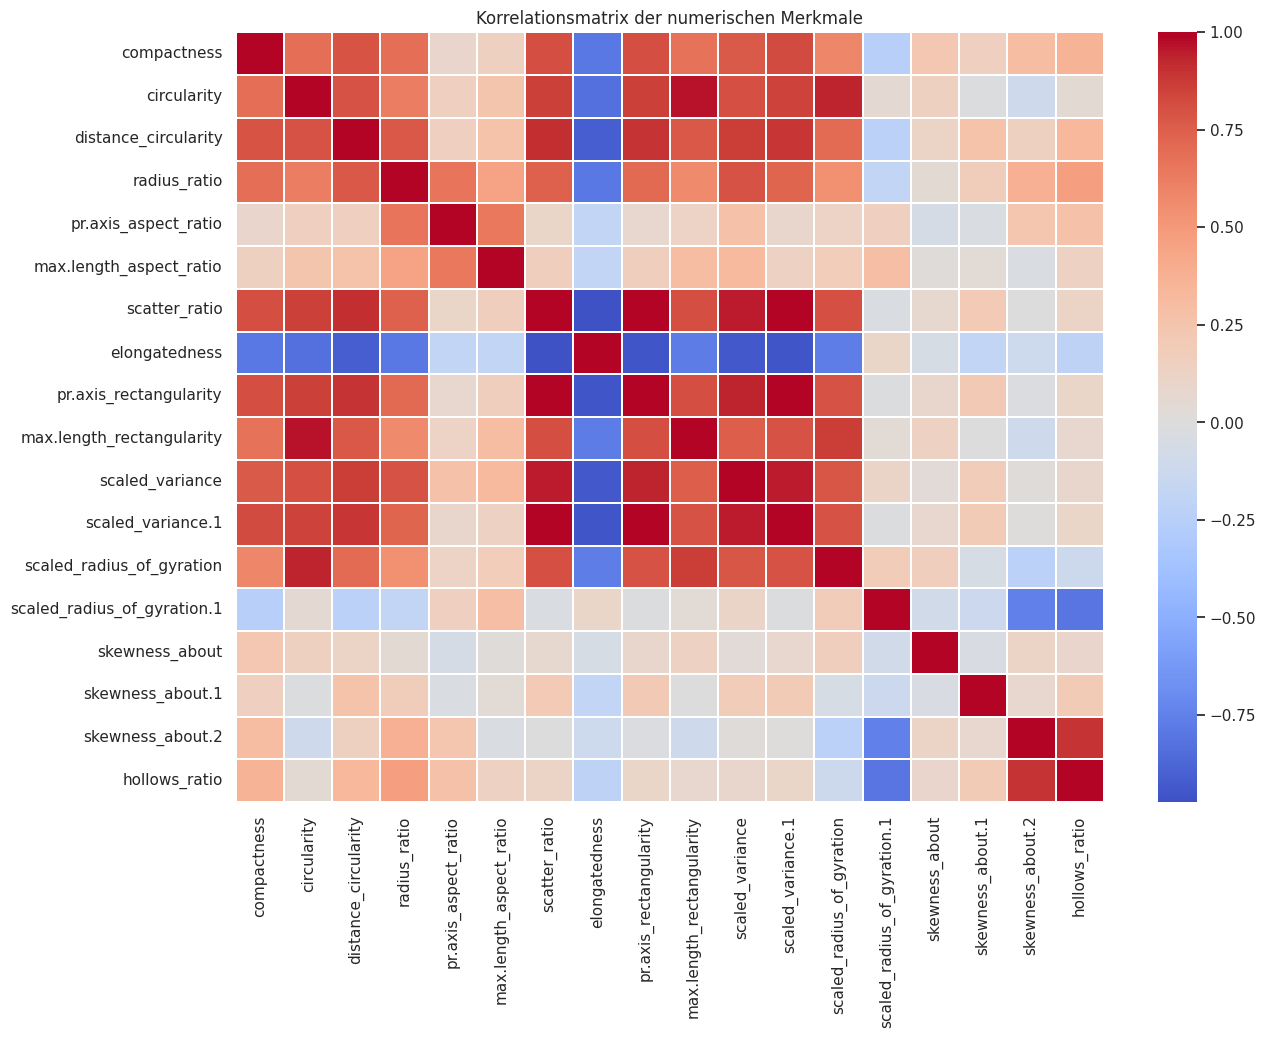

In [9]:
plt.figure(figsize=(14, 10))
corr = df.drop(columns='class').corr(numeric_only=True)
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.2)
plt.title('Korrelationsmatrix der numerischen Merkmale')
plt.show()


## 4. Vorbereitung

Die Zielvariable ist `class`; alle anderen Spalten sind numerische Features. Fehlende Werte werden mit dem Median ersetzt und die Features werden standardisiert.


In [10]:
X = df.drop(columns='class')
y = df['class']
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

numeric_preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[('num', numeric_preprocessor, feature_names)]
)


## 5. Supervised Learning: Klassifikation

Wir vergleichen Logistic Regression, SVM und Random Forest.


In [11]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=3000, random_state=RANDOM_STATE),
    'SVM': SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
}

results = []
trained_models = {}

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy')
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    results.append({
        'model': name,
        'cv_accuracy_mean': cv_scores.mean(),
        'cv_accuracy_std': cv_scores.std(),
        'test_accuracy': accuracy_score(y_test, y_pred)
    })
    trained_models[name] = pipe

results_df = pd.DataFrame(results).sort_values('test_accuracy', ascending=False)
display(results_df)


,model,cv_accuracy_mean,cv_accuracy_std,test_accuracy
1,SVM,0.952680,0.010994,0.970588
2,Random Forest,0.951187,0.007526,0.952941
0,Logistic Regression,0.942298,0.022683,0.935294


Bestes Modell: SVM
Accuracy: 0.9705882352941176
              precision    recall  f1-score   support

         bus       0.98      1.00      0.99        44
         car       0.99      0.95      0.97        86
         van       0.93      0.97      0.95        40

    accuracy                           0.97       170
   macro avg       0.96      0.98      0.97       170
weighted avg       0.97      0.97      0.97       170



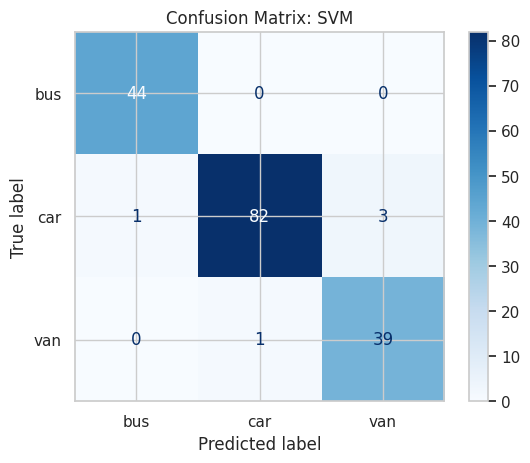

In [12]:
best_model_name = results_df.iloc[0]['model']
best_model = trained_models[best_model_name]
y_pred_best = best_model.predict(X_test)

print('Bestes Modell:', best_model_name)
print('Accuracy:', accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

cm = confusion_matrix(y_test, y_pred_best, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix: {best_model_name}')
plt.show()


### 5.1 Hyperparameter-Tuning mit SVM


In [13]:
svm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', SVC(kernel='rbf', random_state=RANDOM_STATE))
])

param_grid = {
    'model__C': [0.1, 1, 10, 100],
    'model__gamma': ['scale', 0.01, 0.1, 1]
}

grid_search = GridSearchCV(svm_pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print('Beste Parameter:', grid_search.best_params_)
print('Beste CV Accuracy:', grid_search.best_score_)
svm_tuned_pred = grid_search.predict(X_test)
print('Test Accuracy:', accuracy_score(y_test, svm_tuned_pred))
print(classification_report(y_test, svm_tuned_pred))


Beste Parameter: {'model__C': 100, 'model__gamma': 0.1}
Beste CV Accuracy: 0.9807516339869281
Test Accuracy: 0.9705882352941176
              precision    recall  f1-score   support

         bus       0.98      1.00      0.99        44
         car       0.97      0.98      0.97        86
         van       0.97      0.93      0.95        40

    accuracy                           0.97       170
   macro avg       0.97      0.97      0.97       170
weighted avg       0.97      0.97      0.97       170



### 5.2 Feature Importance mit Random Forest


,0
max.length_aspect_ratio,0.140748
scaled_variance.1,0.096625
elongatedness,0.086305
scatter_ratio,0.079535
distance_circularity,0.077581
max.length_rectangularity,0.074902
scaled_variance,0.060783
pr.axis_aspect_ratio,0.053423
scaled_radius_of_gyration.1,0.050357
hollows_ratio,0.042977


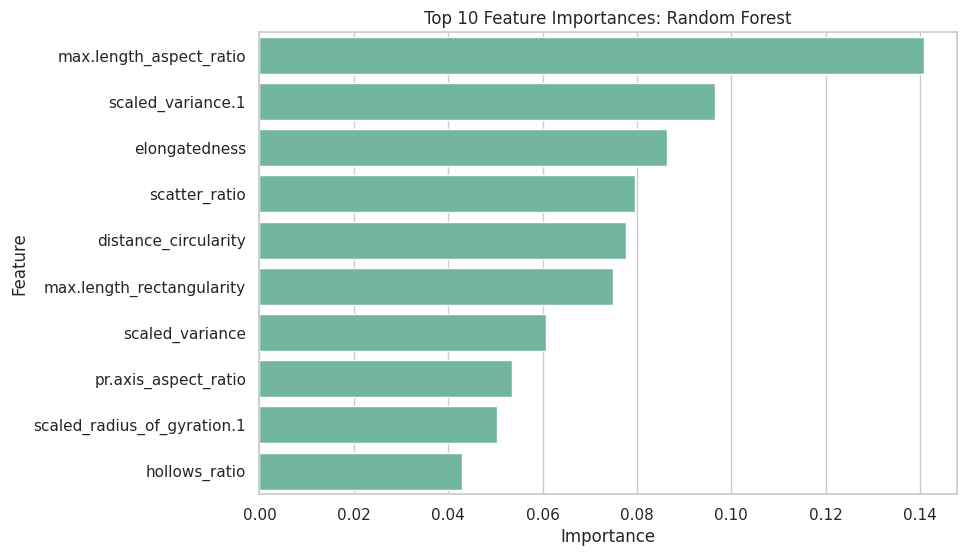

In [14]:
rf_model = trained_models['Random Forest'].named_steps['model']
importances = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False)
display(importances.head(10))

plt.figure(figsize=(9, 6))
sns.barplot(x=importances.head(10).values, y=importances.head(10).index)
plt.title('Top 10 Feature Importances: Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()


## 6. Unsupervised Learning: Clustering

Für Clustering wird `class` nicht verwendet. Danach vergleichen wir die Cluster mit den echten Klassen, um die Struktur zu interpretieren.


In [15]:
unsupervised_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
X_scaled = unsupervised_pipeline.fit_transform(X)
X_scaled.shape


(846, 18)

### 6.1 PCA-Visualisierung


Erklärte Varianz: [0.52186034 0.16729768]
Summe: 0.689158021022674


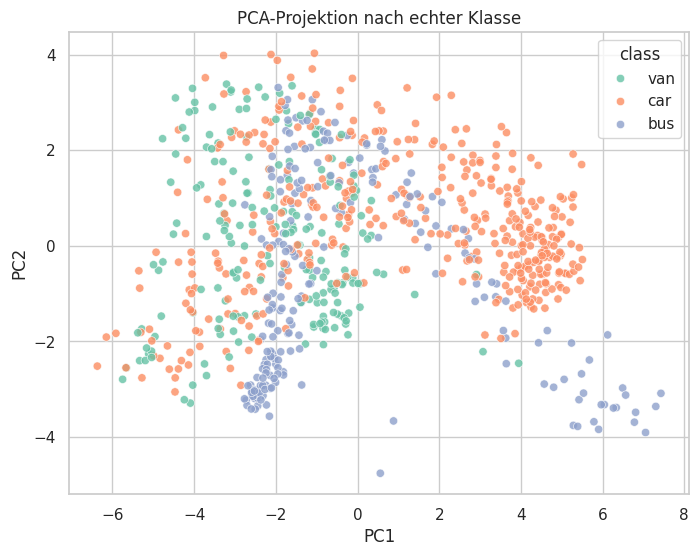

In [16]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['class'] = y.values

print('Erklärte Varianz:', pca.explained_variance_ratio_)
print('Summe:', pca.explained_variance_ratio_.sum())

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='class', alpha=0.8)
plt.title('PCA-Projektion nach echter Klasse')
plt.show()


### 6.2 K-Means mit Elbow-Methode und Silhouette Score


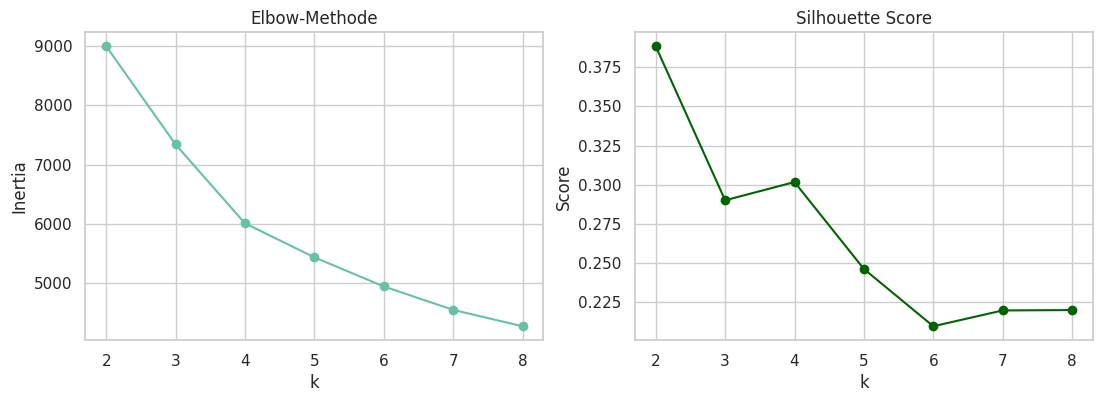

In [17]:
k_values = range(2, 9)
inertias = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(list(k_values), inertias, marker='o')
axes[0].set_title('Elbow-Methode')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[1].plot(list(k_values), silhouette_scores, marker='o', color='darkgreen')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Score')
plt.show()


Silhouette Score k=3: 0.29004705613445647
Adjusted Rand Index gegen echte Klassen: 0.09642453349248725


KMeans Cluster,0,1,2
echte Klasse,,,
bus,50,88,80
car,218,73,138
van,4,88,107


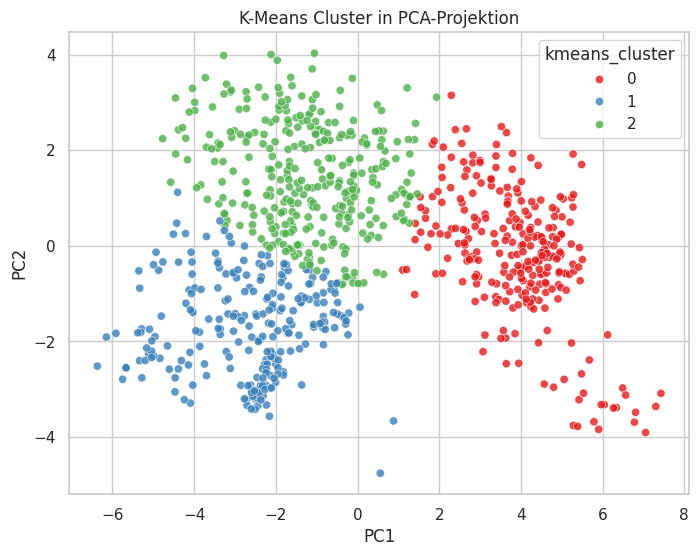

In [18]:
kmeans = KMeans(n_clusters=3, n_init=20, random_state=RANDOM_STATE)
kmeans_labels = kmeans.fit_predict(X_scaled)
pca_df['kmeans_cluster'] = kmeans_labels

print('Silhouette Score k=3:', silhouette_score(X_scaled, kmeans_labels))
print('Adjusted Rand Index gegen echte Klassen:', adjusted_rand_score(y, kmeans_labels))
display(pd.crosstab(y, kmeans_labels, rownames=['echte Klasse'], colnames=['KMeans Cluster']))

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='kmeans_cluster', palette='Set1', alpha=0.8)
plt.title('K-Means Cluster in PCA-Projektion')
plt.show()


### 6.3 Hierarchisches Clustering und DBSCAN


Agglomerative Silhouette: 0.2501882817741658
Agglomerative Adjusted Rand Index: 0.07869495878837385


Agglomerative Cluster,0,1,2
echte Klasse,,,
bus,38,79,101
car,189,160,80
van,6,76,117


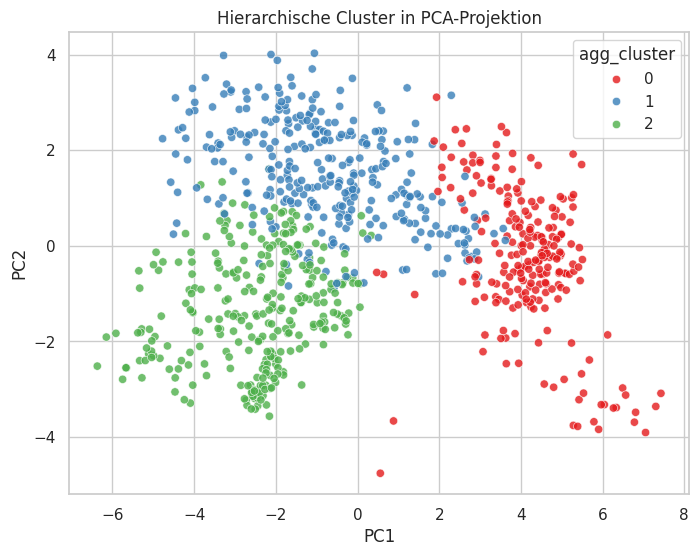

In [19]:
agg = AgglomerativeClustering(n_clusters=3)
agg_labels = agg.fit_predict(X_scaled)

print('Agglomerative Silhouette:', silhouette_score(X_scaled, agg_labels))
print('Agglomerative Adjusted Rand Index:', adjusted_rand_score(y, agg_labels))
display(pd.crosstab(y, agg_labels, rownames=['echte Klasse'], colnames=['Agglomerative Cluster']))

pca_df['agg_cluster'] = agg_labels
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='agg_cluster', palette='Set1', alpha=0.8)
plt.title('Hierarchische Cluster in PCA-Projektion')
plt.show()


DBSCAN Cluster ohne Noise: 1
DBSCAN Noise-Punkte: 15
Silhouette Score nicht sinnvoll, weil weniger als 2 Cluster gefunden wurden.


DBSCAN Label,-1,0
echte Klasse,,
bus,8,210
car,0,429
van,7,192


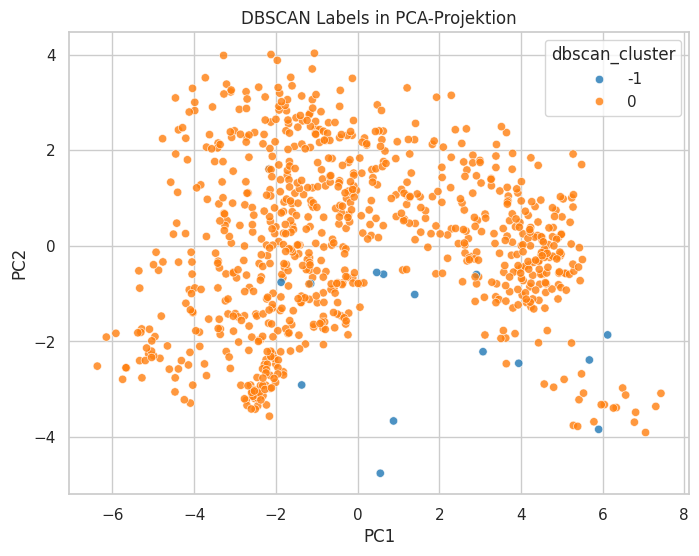

In [20]:
dbscan = DBSCAN(eps=2.5, min_samples=8)
dbscan_labels = dbscan.fit_predict(X_scaled)
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print('DBSCAN Cluster ohne Noise:', n_clusters)
print('DBSCAN Noise-Punkte:', n_noise)
if n_clusters > 1:
    print('DBSCAN Silhouette:', silhouette_score(X_scaled, dbscan_labels))
    print('DBSCAN Adjusted Rand Index:', adjusted_rand_score(y, dbscan_labels))
else:
    print('Silhouette Score nicht sinnvoll, weil weniger als 2 Cluster gefunden wurden.')

display(pd.crosstab(y, dbscan_labels, rownames=['echte Klasse'], colnames=['DBSCAN Label']))
pca_df['dbscan_cluster'] = dbscan_labels
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='dbscan_cluster', palette='tab10', alpha=0.8)
plt.title('DBSCAN Labels in PCA-Projektion')
plt.show()


## 7. Fazit für den Bericht

Ergänze nach dem Ausführen des Notebooks die konkreten Ergebnisse:

- Welches Supervised-Modell die beste Test-Accuracy erreicht.
- Welche Klassen in der Confusion Matrix häufig verwechselt werden.
- Welche Features laut Random Forest besonders wichtig sind.
- Ob K-Means oder hierarchisches Clustering gut zu den echten Klassen passt.

> Supervised Learning eignet sich für diesen Datensatz besser, wenn das Ziel die Vorhersage der Fahrzeugklasse ist, weil die Modelle direkt aus den bekannten Labels lernen. Unsupervised Learning ist trotzdem hilfreich, um natürliche Strukturen und Überschneidungen zwischen Fahrzeugtypen zu erkennen.
